# Perbandingan Hasil: Classical ML vs Quantum ML

Notebook ini **memuat checkpoint `.pkl`** hasil dari [`!ML.ipynb`](!ML.ipynb) (7 model klasik) dan [`!QML.ipynb`](!QML.ipynb) (model kuantum), lalu membandingkannya berdampingan pada konfigurasi (skenario) yang sama.

Tidak ada training di sini — semua angka diambil dari hasil cross-validation yang sudah tersimpan, sehingga membandingkan apel-ke-apel: split, scaler→PCA→SMOTEENN, dan metrik OOF yang identik.

**Yang dibandingkan:**
1. Tabel metrik (mean±std) semua model — highlight pemenang/terburuk
2. Bar chart per metrik (warna = family Classical/Quantum)
3. Confusion matrix OOF semua model
4. F1 per kelas (heatmap)
5. Head-to-head: best classical vs best quantum + verdict

## 0. Konfigurasi perbandingan

Isi skenario **sama persis** seperti di Bagian 1 [`!ML.ipynb`](!ML.ipynb) / [`!QML.ipynb`](!QML.ipynb) — `DROP_CLASSES`, `CUSTOM_TARGETS`, `OVER_METHOD`, `UNDER_METHOD`. Nama file checkpoint (`CONFIG_SLUG`) dihitung otomatis lewat `config_slug()`, jadi **tak perlu menghafal nama file**.

Contoh skenario yang sudah tersedia di `results/checkpoints/`:

| `DROP_CLASSES` | `CUSTOM_TARGETS` | → slug |
|------|------|------|
| `['B']` | `{'E': 'C'}` | `dropB_EC_smoteenn_random` *(config aktif di !QML.ipynb)* |
| `['E']` | `{'B': 'C'}` | `dropE_BC_smoteenn_random` |
| `[]` | `'auto-over'` | `auto-over_smoteenn_random` |

> Pastikan checkpoint skenario ini sudah dibuat dengan menjalankan !ML.ipynb & !QML.ipynb pada config yang sama (lihat tanda ✅/❌ di output sel berikut).

In [16]:
import os
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── ⚙️ Skenario yang ingin dibandingkan ─────────────────────
# Isi PERSIS seperti di !ML.ipynb / !QML.ipynb (Bagian 1). Nama file checkpoint
# dihitung otomatis dari sini lewat config_slug() — tak perlu hafal slug-nya.
DROP_CLASSES   = ['B']          # kelas yang dibuang. [] = pakai semua kelas.
CUSTOM_TARGETS = {'E': 'C'}     # target resample per-kelas. {} = tanpa resampling.
OVER_METHOD    = "smoteenn"     # 'smote' | 'borderline' | 'smoteenn' | 'smotetomek'
UNDER_METHOD   = "random"       # 'random' | 'tomek'

def config_slug():
    """Slug konfigurasi — IDENTIK dengan config_slug() di !ML.ipynb / !QML.ipynb."""
    parts = []
    if DROP_CLASSES:
        parts.append("drop" + "".join(sorted(map(str, DROP_CLASSES))))
    if not CUSTOM_TARGETS:
        parts.append("noresample")
    else:
        t = CUSTOM_TARGETS if isinstance(CUSTOM_TARGETS, str) else \
            "-".join(f"{k}{v}" for k, v in sorted(CUSTOM_TARGETS.items()))
        parts.append(f"{t}_{OVER_METHOD}_{UNDER_METHOD}")
    return re.sub(r"[^A-Za-z0-9._-]+", "-", "_".join(parts) if parts else "default")

CONFIG_SLUG = config_slug()

CKPT_DIR = "./results/checkpoints"
OUT_DIR  = "./results/comparison"
os.makedirs(OUT_DIR, exist_ok=True)

ML_CKPT  = f"{CKPT_DIR}/ml_all_best_{CONFIG_SLUG}.pkl"
QML_CKPT = f"{CKPT_DIR}/qml_all_best_{CONFIG_SLUG}.pkl"
DL_CKPT  = f"{CKPT_DIR}/dl_all_best_{CONFIG_SLUG}.pkl"

print("Config  :", CONFIG_SLUG)
print("ML  ckpt:", ML_CKPT,  "->", "✅" if os.path.exists(ML_CKPT)  else "❌ TIDAK ADA")
print("QML ckpt:", QML_CKPT, "->", "✅" if os.path.exists(QML_CKPT) else "❌ TIDAK ADA")
print("DL  ckpt:", DL_CKPT,  "->", "✅" if os.path.exists(DL_CKPT)  else "❌ TIDAK ADA (opsional)")


Config  : dropB_EC_smoteenn_random
ML  ckpt: ./results/checkpoints/ml_all_best_dropB_EC_smoteenn_random.pkl -> ✅
QML ckpt: ./results/checkpoints/qml_all_best_dropB_EC_smoteenn_random.pkl -> ✅
DL  ckpt: ./results/checkpoints/dl_all_best_dropB_EC_smoteenn_random.pkl -> ✅


In [17]:
# ── Muat kedua checkpoint, tandai family, lalu gabung ──
def load_ckpt(path):
    with open(path, "rb") as f:
        return pickle.load(f)

ml_best  = load_ckpt(ML_CKPT)
qml_best = load_ckpt(QML_CKPT)
dl_best  = load_ckpt(DL_CKPT) if os.path.exists(DL_CKPT) else []

for r in ml_best:
    r["family"] = "Classical"
for r in qml_best:
    r["family"] = "Quantum"
for r in dl_best:
    r["family"] = "Deep Learning"

all_models = ml_best + qml_best + dl_best
print(f"Classical: {len(ml_best)} | Quantum: {len(qml_best)} | Deep Learning: {len(dl_best)} | total {len(all_models)}")
print("  Classical    :", [r['model'] for r in ml_best])
print("  Quantum      :", [r['model'] for r in qml_best])
print("  Deep Learning:", [r['model'] for r in dl_best])

# Helper: ambil bagian mean dari string 'mean±std' (± = chr(177)) atau angka.
def _mean(v):
    try:
        return float(str(v).split(chr(177))[0])
    except (ValueError, TypeError):
        return np.nan

# Helper: nama kelas asli (A/B/C/D/...) dari report_dict.
def class_names_of(r):
    return [k for k in r['report_dict'] if k not in ('accuracy', 'macro avg', 'weighted avg')]


Classical: 7 | Quantum: 3 | Deep Learning: 2 | total 12
  Classical    : ['SVC Linear', 'SVC Poly', 'SVC RBF', 'SVC Sigmoid', 'XGBoost GBTree', 'XGBoost Dart', 'CatBoost']
  Quantum      : ['QSVC - Circular', 'QSVC - Full', 'QSVC - Linear']
  Deep Learning: ['MLP', '1D CNN']


## 1. Tabel perbandingan metrik (mean ± std)

Diurutkan berdasarkan ROC-AUC. 🟢 hijau = nilai terbaik per metrik, 🔴 merah = terburuk. Kolom `Family` diberi warna: biru muda = Quantum, oranye muda = Classical.

In [18]:
rows = []
for r in all_models:
    rows.append({
        "Family"    : r["family"],
        "Model"     : r["model"],
        "Accuracy"  : r["acc"],
        "Precision" : r["prec"],
        "Recall"    : r["rec"],
        "F1-Score"  : r["f1"],
        "ROC-AUC"   : r["roc"],
        "PR-AUC"    : r["pra"],
        "Log-Loss"  : r.get("loss", "N/A"),
        "MCC"       : r.get("mcc", "N/A"),
        "Exec.(s)"  : round(r["execution_time"], 2) if "execution_time" in r else "N/A",
    })
cmp_df = pd.DataFrame(rows)
cmp_df = cmp_df.sort_values("ROC-AUC", key=lambda c: c.map(_mean), ascending=False).reset_index(drop=True)
cmp_df.index += 1

_higher = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC', 'MCC']
_lower  = ['Log-Loss', 'Exec.(s)']

def _hl_win_lose(col):
    if col.name not in _higher + _lower:
        return [''] * len(col)
    vals = col.map(_mean)
    if vals.notna().sum() == 0:
        return [''] * len(col)
    win  = vals.max() if col.name in _higher else vals.min()
    lose = vals.min() if col.name in _higher else vals.max()
    out = []
    for v in vals:
        if v == win:
            out.append('background-color:#b6e7b0;color:#14532d;font-weight:bold')
        elif v == lose:
            out.append('background-color:#f4b6b6;color:#7f1d1d')
        else:
            out.append('')
    return out

def _hl_family(col):
    if col.name != 'Family':
        return [''] * len(col)
    _fam_bg = {'Quantum': '#e6f0ff', 'Classical': '#fff3e6', 'Deep Learning': '#eaf7ea'}
    return [f'background-color:{_fam_bg.get(v, "")}' for v in col]

styled = cmp_df.style.apply(_hl_win_lose, axis=0).apply(_hl_family, axis=0)
display(styled)

cmp_df.to_csv(f"{OUT_DIR}/comparison_table_{CONFIG_SLUG}.csv", index=True)
print("✅ Saved:", f"{OUT_DIR}/comparison_table_{CONFIG_SLUG}.csv")


,Family,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Log-Loss,MCC,Exec.(s)
1,Deep Learning,1D CNN,0.9633,0.9526,0.9628,0.9576,0.9980,0.9903,0.1011,0.9466,45.240000
2,Quantum,QSVC - Linear,0.9683±0.0038,0.9538±0.0050,0.9677±0.0046,0.9604±0.0046,0.9974±0.0007,0.9884±0.0032,0.0924±0.0116,0.9540,66.930000
3,Quantum,QSVC - Circular,0.9682±0.0036,0.9537±0.0049,0.9674±0.0044,0.9602±0.0045,0.9974±0.0007,0.9884±0.0032,0.0925±0.0113,0.9539,69.470000
4,Quantum,QSVC - Full,0.9678±0.0042,0.9532±0.0056,0.9671±0.0047,0.9598±0.0050,0.9974±0.0008,0.9885±0.0032,0.0924±0.0119,0.9533,71.100000
5,Deep Learning,MLP,0.9515,0.9373,0.9492,0.9428,0.9970,0.9873,0.1309,0.9299,39.110000
6,Classical,XGBoost GBTree,0.9533±0.0042,0.9411±0.0040,0.9524±0.0050,0.9463±0.0040,0.9958±0.0006,0.9854±0.0015,0.1607±0.0083,0.9324,7.780000
7,Classical,SVC RBF,0.9412±0.0057,0.9261±0.0050,0.9461±0.0042,0.9347±0.0047,0.9933±0.0016,0.9757±0.0058,0.1678±0.0216,0.9163,13.560000
8,Classical,CatBoost,0.9299±0.0063,0.9166±0.0057,0.9213±0.0094,0.9177±0.0076,0.9923±0.0008,0.9720±0.0045,0.3031±0.0083,0.8988,14.270000
9,Classical,SVC Poly,0.8590±0.0055,0.8513±0.0055,0.8849±0.0048,0.8635±0.0048,0.9768±0.0029,0.9366±0.0084,0.3560±0.0223,0.8035,20.890000
10,Classical,XGBoost Dart,0.8011±0.0069,0.8286±0.0077,0.7687±0.0117,0.7717±0.0109,0.9620±0.0033,0.8944±0.0062,0.7500±0.0042,0.7237,25.640000


✅ Saved: ./results/comparison/comparison_table_dropB_EC_smoteenn_random.csv


## 2. Bar chart per metrik

Satu subplot per metrik; tiap bar = satu model, warna mengikuti family (biru = Classical, oranye = Quantum). Memudahkan melihat siapa unggul di metrik tertentu.

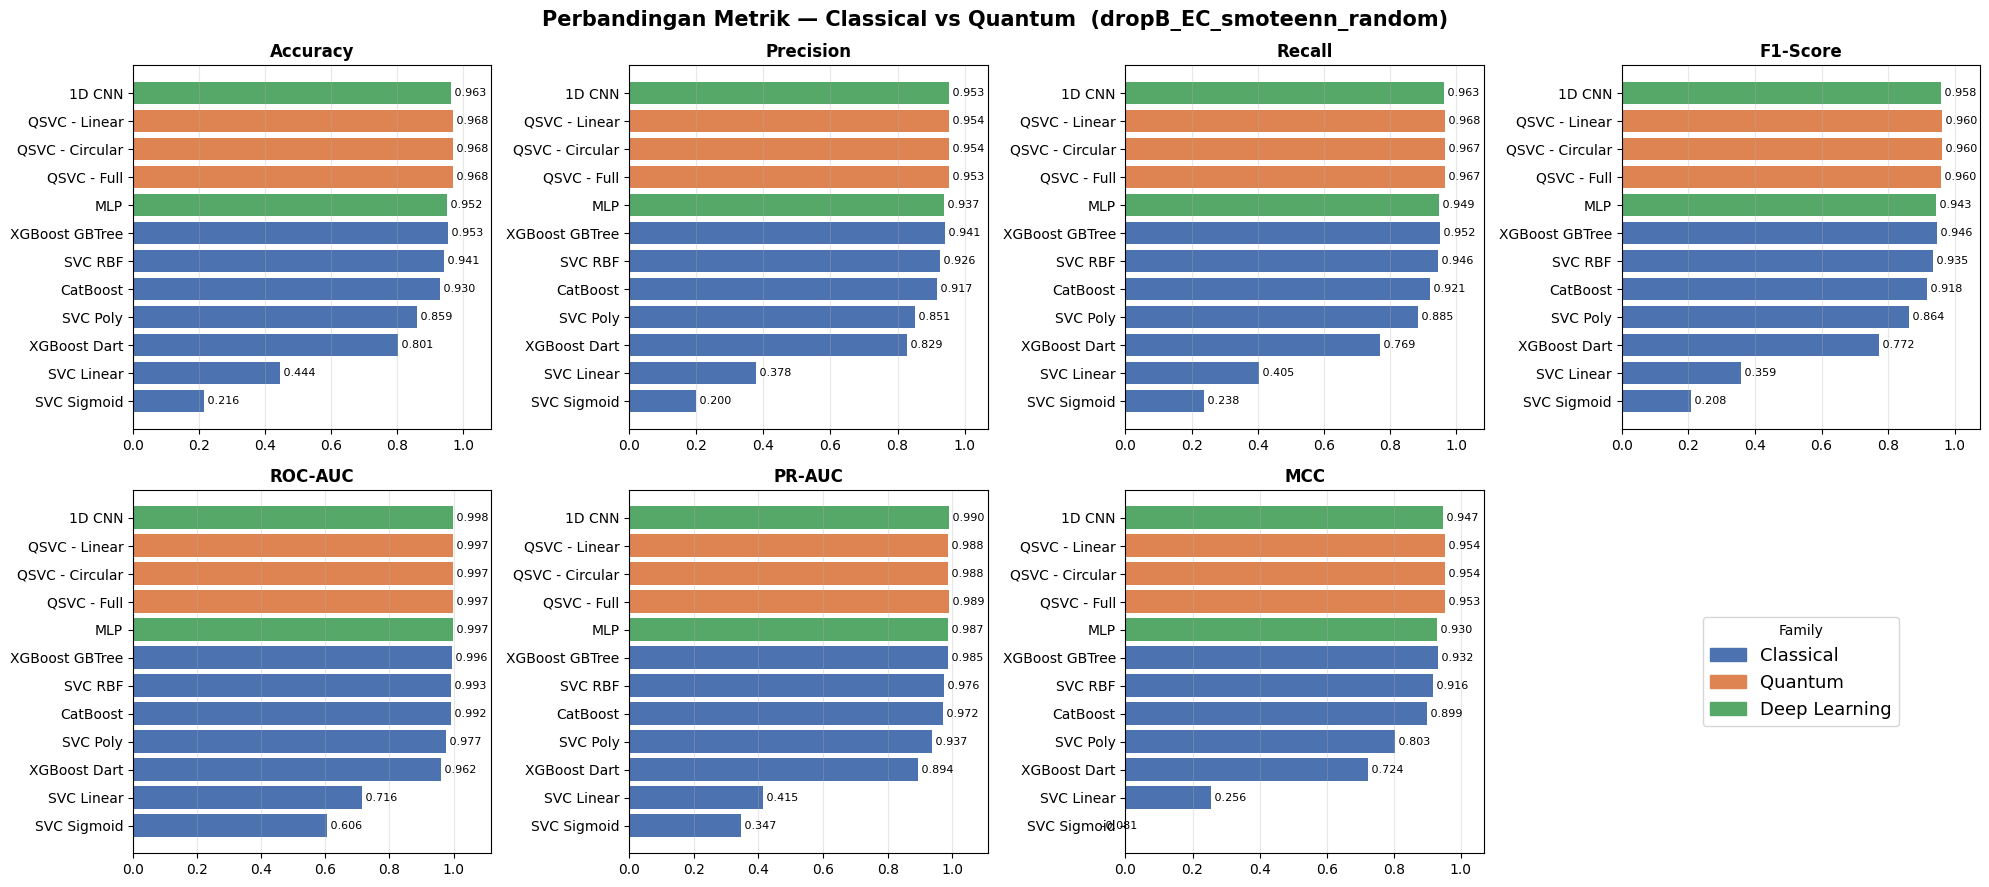

✅ Saved: ./results/comparison/comparison_metrics_dropB_EC_smoteenn_random.png


In [19]:
from matplotlib.patches import Patch

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC', 'MCC']
plot_df = cmp_df.set_index('Model')[metrics].apply(lambda c: c.map(_mean))
fam = cmp_df.set_index('Model')['Family']
_fam_color = {'Classical': '#4C72B0', 'Quantum': '#DD8452', 'Deep Learning': '#55A868'}
colors = [_fam_color.get(fam[m], '#999999') for m in plot_df.index]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.ravel()
for ax, met in zip(axes, metrics):
    vals = plot_df[met]
    ax.barh(plot_df.index, vals, color=colors)
    ax.invert_yaxis()
    ax.set_title(met, fontweight='bold')
    ax.set_xlim(0, max(1.0, float(vals.max()) * 1.12))
    for i, v in enumerate(vals):
        ax.text(v, i, f' {v:.3f}', va='center', fontsize=8)
    ax.grid(True, axis='x', alpha=0.3)

axes[-1].axis('off')
axes[-1].legend(
    handles=[Patch(color='#4C72B0', label='Classical'),
             Patch(color='#DD8452', label='Quantum'),
             Patch(color='#55A868', label='Deep Learning')],
    loc='center', fontsize=13, title='Family')
fig.suptitle(f'Perbandingan Metrik — Classical vs Quantum  ({CONFIG_SLUG})',
             fontsize=15, fontweight='bold')
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/comparison_metrics_{CONFIG_SLUG}.png", dpi=130, bbox_inches='tight')
plt.show()
print("✅ Saved:", f"{OUT_DIR}/comparison_metrics_{CONFIG_SLUG}.png")


## 3. Confusion matrix (out-of-fold) semua model

Dari prediksi OOF (`y_true`/`y_pred`) yang disimpan tiap model saat CV — mencerminkan generalisasi. Prefix `[C]`/`[Q]` menandai Classical/Quantum.

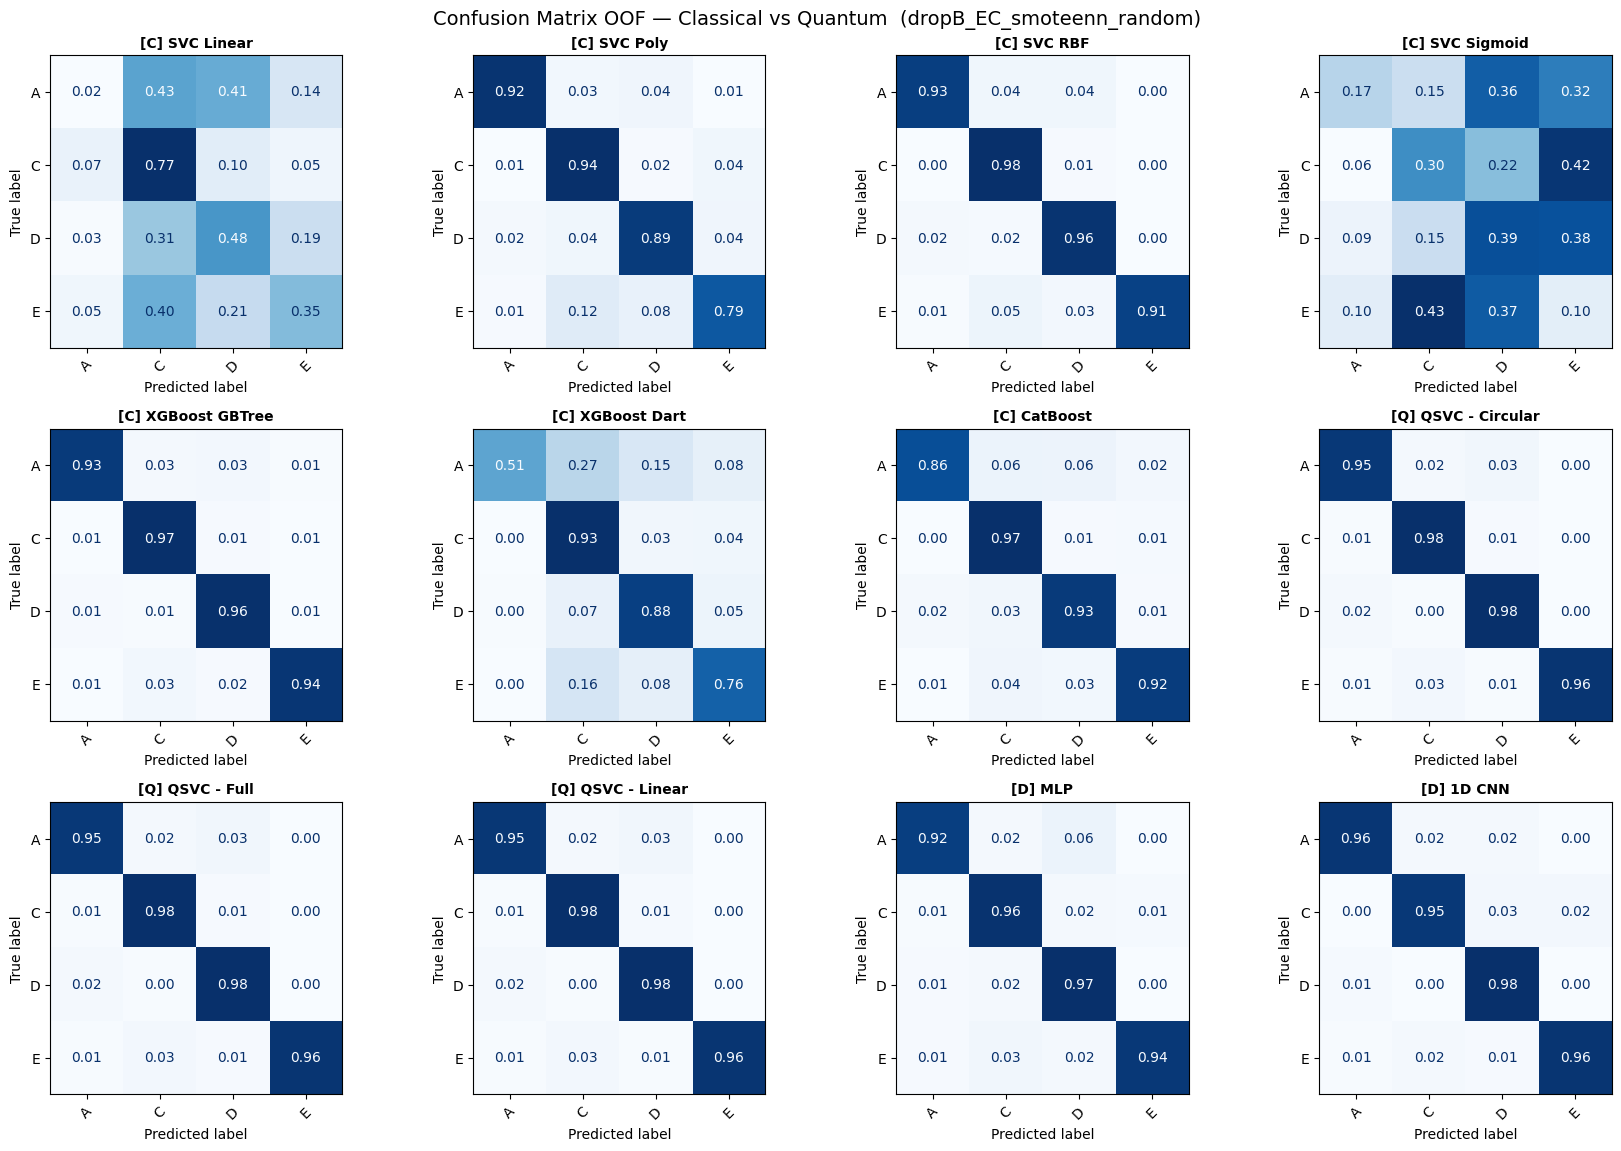

✅ Saved: ./results/comparison/comparison_confusion_dropB_EC_smoteenn_random.png


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cms = [r for r in all_models if 'y_true' in r and 'y_pred' in r]
n = len(cms)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.3 * ncols, 3.9 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, r in zip(axes, cms):
    cn = class_names_of(r)
    labels = np.arange(len(cn))
    cm = confusion_matrix(r['y_true'], r['y_pred'], labels=labels)
    ConfusionMatrixDisplay(cm, display_labels=cn).plot(
        ax=ax, cmap='Blues', colorbar=False, values_format='d')
    ax.set_title(f"[{r['family'][0]}] {r['model']}", fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)

for ax in axes[n:]:
    ax.axis('off')
fig.suptitle(f'Confusion Matrix OOF — Classical vs Quantum  ({CONFIG_SLUG})', fontsize=14)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/comparison_confusion_{CONFIG_SLUG}.png", dpi=140, bbox_inches='tight')
plt.show()
print("✅ Saved:", f"{OUT_DIR}/comparison_confusion_{CONFIG_SLUG}.png")

## 4. F1 per kelas (heatmap)

Membandingkan kemampuan tiap model di kelas yang sulit. Diambil dari `report_dict` (classification report OOF). Baris diurutkan sesuai ranking ROC-AUC.

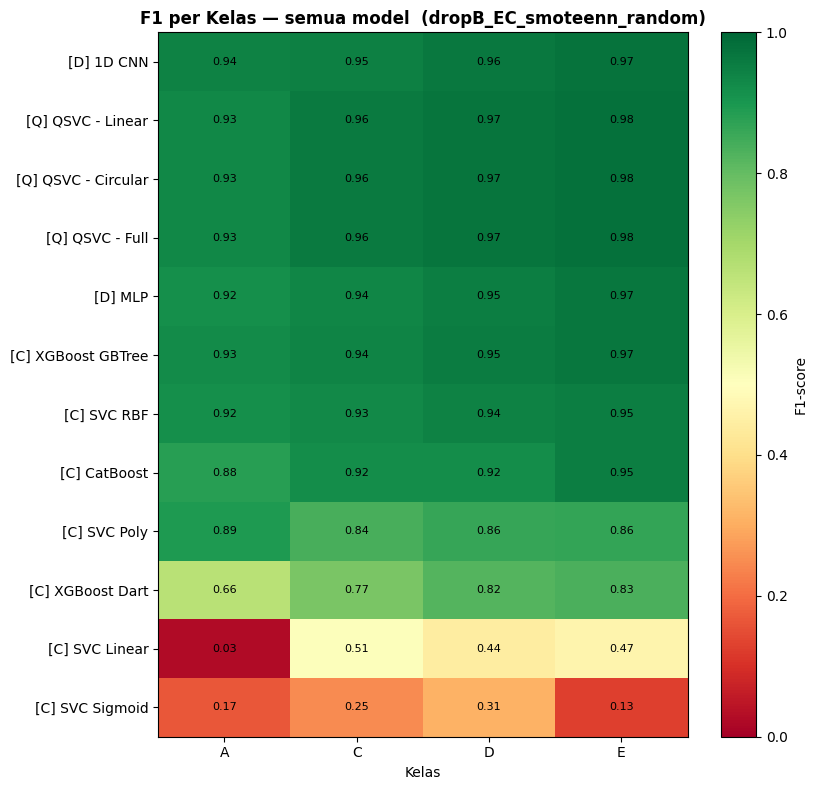

✅ Saved: ./results/comparison/comparison_f1_perclass_dropB_EC_smoteenn_random.png


In [21]:
per_class = {}
for r in all_models:
    cn = class_names_of(r)
    per_class[r['model']] = {c: r['report_dict'][c]['f1-score'] for c in cn}
f1_df = pd.DataFrame(per_class).T
f1_df = f1_df.loc[cmp_df['Model']]   # urut sesuai ranking tabel

fig, ax = plt.subplots(figsize=(1.1 * len(f1_df.columns) + 4, 0.5 * len(f1_df) + 2))
im = ax.imshow(f1_df.values, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(f1_df.columns)))
ax.set_xticklabels(f1_df.columns)
ax.set_yticks(range(len(f1_df)))
ax.set_yticklabels([f"[{fam[m][0]}] {m}" for m in f1_df.index])
for i in range(len(f1_df)):
    for j in range(len(f1_df.columns)):
        ax.text(j, i, f"{f1_df.values[i, j]:.2f}", ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=ax, label='F1-score')
ax.set_xlabel('Kelas')
ax.set_title(f'F1 per Kelas — semua model  ({CONFIG_SLUG})', fontweight='bold')
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/comparison_f1_perclass_{CONFIG_SLUG}.png", dpi=140, bbox_inches='tight')
plt.show()
f1_df.to_csv(f"{OUT_DIR}/comparison_f1_perclass_{CONFIG_SLUG}.csv")
print("✅ Saved:", f"{OUT_DIR}/comparison_f1_perclass_{CONFIG_SLUG}.png")

## 5. Head-to-head: best per family (Classical vs Deep Learning vs Quantum)

Model terbaik tiap family dipilih berdasarkan skor `composite` ((AUROC+PRAUC+Acc)/3, kriteria yang sama dengan training). Sel **hijau** = family pemenang untuk metrik tersebut (3-way; untuk `Log-Loss` makin kecil makin baik). Kolom **Keunggulan Quantum (+)** = selisih Quantum − Classical yang sudah disearahkan sehingga **positif = quantum lebih baik** (untuk `Log-Loss` tandanya dibalik). Deep Learning hanya muncul bila checkpoint-nya tersedia.


In [22]:
def best_of(models):
    return max(models, key=lambda r: r.get('composite', _mean(r['roc'])))

# Best per family (Deep Learning opsional — hanya bila checkpoint-nya ada).
bc  = best_of(ml_best)    # best classical
bq  = best_of(qml_best)   # best quantum
bdl = best_of(dl_best) if dl_best else None  # best deep learning

fam_best = {'Classical': bc, 'Quantum': bq}
if bdl is not None:
    fam_best['Deep Learning'] = bdl
# Urutan kolom: Classical, Deep Learning (bila ada), Quantum.
fam_order = [f for f in ['Classical', 'Deep Learning', 'Quantum'] if f in fam_best]
col_label = {f: f'{f}: {fam_best[f]["model"]}' for f in fam_order}

metrics8 = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC', 'Log-Loss', 'MCC']
keys8    = ['acc', 'prec', 'rec', 'f1', 'roc', 'pra', 'loss', 'mcc']
_lower_set = {'Log-Loss'}   # makin kecil makin baik

rows = []
wins   = {f: 0 for f in fam_order}   # menang metrik tiap family (3-way)
q_wins = c_wins = 0                  # head-to-head Quantum vs Classical (sumbu utama tesis)
for m, k in zip(metrics8, keys8):
    vals = {f: _mean(fam_best[f][k]) for f in fam_order}
    winner = (min if m in _lower_set else max)(vals, key=vals.get)
    wins[winner] += 1
    adv = (vals['Classical'] - vals['Quantum']) if m in _lower_set else (vals['Quantum'] - vals['Classical'])
    if   adv > 0: q_wins += 1
    elif adv < 0: c_wins += 1
    row = {'Metrik': m}
    for f in fam_order:
        row[col_label[f]] = fam_best[f][k]
    row['Pemenang'] = winner
    row['Keunggulan Quantum (+)'] = adv
    rows.append(row)
h2h = pd.DataFrame(rows).set_index('Metrik')

# Highlight sel family pemenang per metrik (hijau) + gradient keunggulan Q vs C.
def _hl_winner(row):
    win_col = col_label[row['Pemenang']]
    return ['background-color:#b6e7b0;color:#14532d;font-weight:bold' if c == win_col else ''
            for c in row.index]

display(h2h.style
        .apply(_hl_winner, axis=1)
        .format({'Keunggulan Quantum (+)': '{:+.4f}'})
        .background_gradient(cmap='RdYlGn', subset=['Keunggulan Quantum (+)']))

h2h.to_csv(f"{OUT_DIR}/comparison_head2head_{CONFIG_SLUG}.csv")
print("✅ Saved:", f"{OUT_DIR}/comparison_head2head_{CONFIG_SLUG}.csv")

# ── Verdict ──
print("\n" + "=" * 60)
print(f"VERDICT ({CONFIG_SLUG})")
print("=" * 60)
print("  Best per family (composite):")
for f in fam_order:
    print(f"    {f:<14}: {fam_best[f]['model']:<22} composite={fam_best[f].get('composite', float('nan')):.4f}")
print("  Menang metrik (3-way)    : " + " | ".join(f"{f} {wins[f]}" for f in fam_order)
      + f"  (dari {len(metrics8)} metrik)")
print(f"  Head-to-head Q vs C      : Quantum {q_wins}  vs  Classical {c_wins}")
best_fam = max(fam_order, key=lambda f: fam_best[f].get('composite', float('-inf')))
print(f"  🏆 Composite tertinggi   : {best_fam} ({fam_best[best_fam]['model']})")


,Classical: XGBoost GBTree,Deep Learning: 1D CNN,Quantum: QSVC - Linear,Pemenang,Keunggulan Quantum (+)
Metrik,,,,,
Accuracy,0.9533±0.0042,0.9633,0.9683±0.0038,Quantum,+0.0150
Precision,0.9411±0.0040,0.9526,0.9538±0.0050,Quantum,+0.0127
Recall,0.9524±0.0050,0.9628,0.9677±0.0046,Quantum,+0.0153
F1-Score,0.9463±0.0040,0.9576,0.9604±0.0046,Quantum,+0.0141
ROC-AUC,0.9958±0.0006,0.9980,0.9974±0.0007,Deep Learning,+0.0016
PR-AUC,0.9854±0.0015,0.9903,0.9884±0.0032,Deep Learning,+0.0030
Log-Loss,0.1607±0.0083,0.1011,0.0924±0.0116,Quantum,+0.0683
MCC,0.9324,0.9466,0.9540,Quantum,+0.0216


✅ Saved: ./results/comparison/comparison_head2head_dropB_EC_smoteenn_random.csv

VERDICT (dropB_EC_smoteenn_random)
  Best per family (composite):
    Classical     : XGBoost GBTree         composite=0.9782
    Deep Learning : 1D CNN                 composite=0.9839
    Quantum       : QSVC - Linear          composite=0.9847
  Menang metrik (3-way)    : Classical 0 | Deep Learning 2 | Quantum 6  (dari 8 metrik)
  Head-to-head Q vs C      : Quantum 8  vs  Classical 0
  🏆 Composite tertinggi   : Quantum (QSVC - Linear)
